In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. LOAD & EXPLORE DATA

In [2]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/2020_05.csv')
df.head(10)


,date,train_id,stop_sequence,from,from_id,to,to_id,scheduled_time,actual_time,delay_minutes,status,line,type
0,2020-05-01,5543,1.0,Newark Penn Station,107,Newark Penn Station,107,2020-05-01 23:38:00,2020-05-01 23:40:09,2.150000,departed,Raritan Valley,NJ Transit
1,2020-05-01,5543,2.0,Newark Penn Station,107,Union,38105,2020-05-01 23:47:00,2020-05-01 23:47:01,0.016667,departed,Raritan Valley,NJ Transit
2,2020-05-01,5543,3.0,Union,38105,Roselle Park,31,2020-05-01 23:50:00,2020-05-01 23:51:04,1.066667,departed,Raritan Valley,NJ Transit
3,2020-05-01,5543,4.0,Roselle Park,31,Cranford,32,2020-05-01 23:55:00,2020-05-01 23:55:31,0.516667,departed,Raritan Valley,NJ Transit
4,2020-05-01,5543,5.0,Cranford,32,Westfield,155,2020-05-01 23:59:00,2020-05-01 23:59:01,0.016667,departed,Raritan Valley,NJ Transit
5,2020-05-01,5543,6.0,Westfield,155,Fanwood,44,2020-05-02 00:04:00,2020-05-02 00:03:21,0.000000,departed,Raritan Valley,NJ Transit
6,2020-05-01,5543,7.0,Fanwood,44,Netherwood,102,2020-05-02 00:07:00,2020-05-02 00:07:10,0.166667,departed,Raritan Valley,NJ Transit
7,2020-05-01,5543,8.0,Netherwood,102,Plainfield,120,2020-05-02 00:11:00,2020-05-02 00:09:05,0.000000,departed,Raritan Valley,NJ Transit
8,2020-05-01,5543,9.0,Plainfield,120,Dunellen,36,2020-05-02 00:16:00,2020-05-02 00:13:01,0.000000,departed,Raritan Valley,NJ Transit
9,2020-05-01,5543,10.0,Dunellen,36,Bound Brook,21,2020-05-02 00:21:00,2020-05-02 00:19:07,0.000000,departed,Raritan Valley,NJ Transit


In [3]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98698 entries, 0 to 98697
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            98698 non-null  object 
 1   train_id        98698 non-null  object 
 2   stop_sequence   87172 non-null  float64
 3   from            98698 non-null  object 
 4   from_id         98698 non-null  int64  
 5   to              98698 non-null  object 
 6   to_id           98698 non-null  int64  
 7   scheduled_time  87172 non-null  object 
 8   actual_time     98698 non-null  object 
 9   delay_minutes   87172 non-null  float64
 10  status          98698 non-null  object 
 11  line            98698 non-null  object 
 12  type            98698 non-null  object 
dtypes: float64(2), int64(2), object(9)
memory usage: 9.8+ MB


In [4]:
df['status'].value_counts()

,count
status,
departed,87547
estimated,8573
cancelled,2578


In [5]:
df[df['delay_minutes'].isnull()]['status'].value_counts()

,count
status,
departed,10685
estimated,749
cancelled,92


## 2. DATA CLEANING

In [6]:
df_clean = df.dropna(subset=['delay_minutes']).copy()
df_clean.shape

(87172, 13)

In [7]:
df_clean['delay_minutes'].describe() # to analyze the target data, is there a outlier?



,delay_minutes
count,87172.000000
mean,3.281289
std,10.253101
min,0.000000
25%,0.116667
50%,1.200000
75%,3.083333
max,182.000000


In [8]:
# creating target column "is_delayed"
df_clean['is_delayed'] = (df_clean['delay_minutes'] > 5).astype(int) # checks evry row and returns T/F if delay>5 and converts into 1/0
df_clean['is_delayed'].value_counts() #How many in each class

#Result below says: About 76,496 trains are on time (88%) and 10676 are delayed


,count
is_delayed,
0,76496
1,10676


In [9]:
df_clean[['date', 'scheduled_time']].head() # to check format of data
# converting the format to real datetime
df_clean['scheduled_time'] = pd.to_datetime(df_clean['scheduled_time'])
df_clean['hour'] = df_clean['scheduled_time'].dt.hour #extract hour
df_clean['day_of_week'] = df_clean['scheduled_time'].dt.dayofweek #extract day

df_clean[['scheduled_time', 'hour', 'day_of_week']].head()

,scheduled_time,hour,day_of_week
0,2020-05-01 23:38:00,23,4
1,2020-05-01 23:47:00,23,4
2,2020-05-01 23:50:00,23,4
3,2020-05-01 23:55:00,23,4
4,2020-05-01 23:59:00,23,4


In [10]:
df_clean.groupby('hour')['is_delayed'].mean() #splits data into grps (0,1,....23),
#within each grp look at is_delayed column and averag

# what does below data mean: hour 17 (5pm) shows 0.17,
#that mean 17% of trains scheduled around 5pm were delayed


,is_delayed
hour,
0,0.133108
1,0.235910
2,0.202929
3,0.000000
4,0.007782
5,0.083930
6,0.077624
7,0.091831
8,0.084540


In [11]:
df_clean.groupby('day_of_week')['is_delayed'].mean() # same idea as above
#monday = 0

,is_delayed
day_of_week,
0,0.135000
1,0.139884
2,0.134273
3,0.131204
4,0.130218
5,0.111724
6,0.078968


In [12]:
df_clean.groupby('hour')['is_delayed'].count()
#This counts how many rows fall into each hour. If hours 1-4am have only a handful of rows each,
#we will know those percentages are noise

,is_delayed
hour,
0,1480
1,1242
2,478
3,67
4,257
5,1537
6,3839
7,5423
8,5110


## 3. FEATURE ENGINEERING
(ONE-HOT ENCODING)

In [14]:
#ONE HOT ENCODING, TO TURN TEXT INTO NUMBERS FOR SCKIT-LEARN MODEL

features = ['hour', 'day_of_week', 'line', 'type']
X = pd.get_dummies(df_clean[features], columns=['line', 'type']).astype(int)
y = df_clean['is_delayed']

X.head()

,hour,day_of_week,line_Atl. City Line,line_Bergen Co. Line,line_Gladstone Branch,line_Main Line,line_Montclair-Boonton,line_Morristown Line,line_No Jersey Coast,line_Northeast Corrdr,line_Pascack Valley,line_Princeton Shuttle,line_Raritan Valley,type_NJ Transit
0,23,4,0,0,0,0,0,0,0,0,0,0,1,1
1,23,4,0,0,0,0,0,0,0,0,0,0,1,1
2,23,4,0,0,0,0,0,0,0,0,0,0,1,1
3,23,4,0,0,0,0,0,0,0,0,0,0,1,1
4,23,4,0,0,0,0,0,0,0,0,0,0,1,1


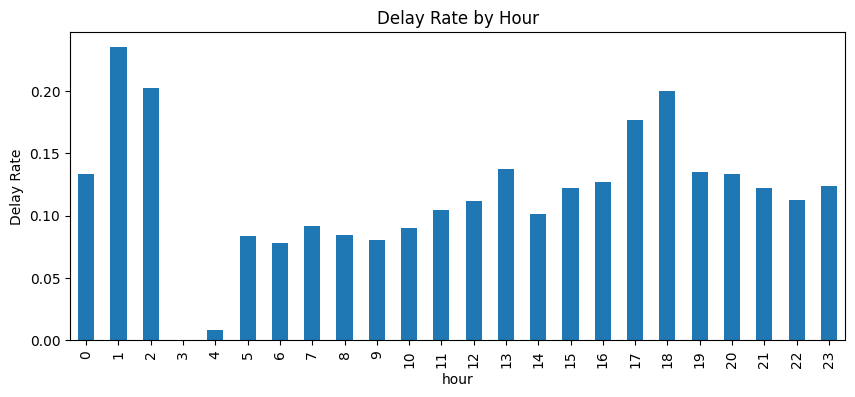

In [25]:
import matplotlib.pyplot as plt

df_clean.groupby('hour')['is_delayed'].mean().plot(kind='bar', figsize=(10,4), title='Delay Rate by Hour')
plt.ylabel('Delay Rate')
plt.savefig('delay_by_hour.png')
plt.show()

## 4. TRAIN/TEST SPLIT

In [15]:
#Train/Test/Split

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                test_size=0.2, stratify=y,random_state=42)

X_train.shape, X_test.shape
# test size = 0.2 holds 20% data for testing.
# stratify=y keeps that same 88/12 on-time/delayed ratio in both pieces
# random state makes split reproducible


((69737, 14), (17435, 14))

## 5. MODEL COMPARISONS

In [16]:
# model training - Logistic Regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [21]:
# checking if it is working on test data
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test) # runs model on rows it has never seen before
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred)) # prints precision, recall, F1 score

# Reading class 1 (delayed) — the row that actually matters:

# precision = 0.70 → out of all the times your model predicted "delayed," it was right 70% of the time. Decent.
# recall = 0.11 → out of all the trains that were actually delayed (2,135 of them — that's the "support" number), your model only caught 11% of them. It missed nearly 9 out of 10 real delays.
# f1-score = 0.19 → this combines precision and recall into one number; it's low here specifically because recall is so bad.

# basically, it only says delayed whn it is very confident but stays silent
# on most actual delays rather than take the risk.

0.8854029251505592
              precision    recall  f1-score   support

           0       0.89      0.99      0.94     15300
           1       0.70      0.11      0.19      2135

    accuracy                           0.89     17435
   macro avg       0.80      0.55      0.57     17435
weighted avg       0.87      0.89      0.85     17435



In [22]:
# Logistic model - balanced (treating mistakes on minority class as more costly than mistakes on majority class)
model_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')
model_balanced.fit(X_train, y_train)

y_pred_balanced = model_balanced.predict(X_test)
print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.92      0.73      0.81     15300
           1       0.22      0.55      0.31      2135

    accuracy                           0.71     17435
   macro avg       0.57      0.64      0.56     17435
weighted avg       0.83      0.71      0.75     17435



In [23]:
#RANDOM FOREST MODEL
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.95      0.72      0.82     15300
           1       0.27      0.72      0.39      2135

    accuracy                           0.72     17435
   macro avg       0.61      0.72      0.60     17435
weighted avg       0.86      0.72      0.77     17435



## 6. FEATURE IMPORTANCE


In [24]:
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
importances

,0
hour,0.470371
day_of_week,0.173652
line_Atl. City Line,0.130320
line_Montclair-Boonton,0.059409
line_Northeast Corrdr,0.034965
line_Morristown Line,0.027480
line_No Jersey Coast,0.026577
line_Gladstone Branch,0.018788
line_Pascack Valley,0.013959
line_Main Line,0.013038
